In [1]:
from sklearn.linear_model import LinearRegression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [5]:
df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [6]:
df['Age'].isna().sum()

np.int64(177)

<Axes: xlabel='Sex', ylabel='Survived'>

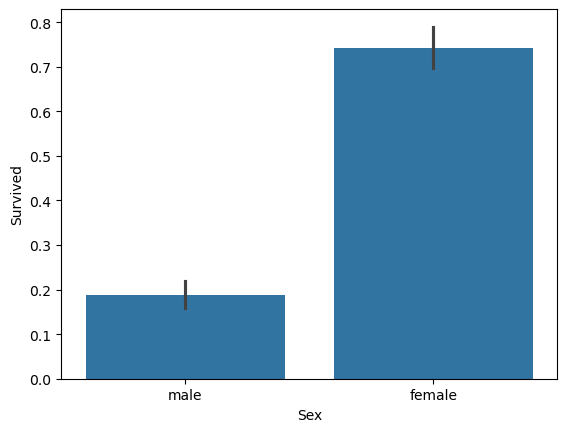

In [7]:
sns.barplot(data=df, x="Sex", y="Survived")

In [8]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [9]:
grouped = df.groupby(['Embarked', 'Pclass']).size()
grouped

Embarked  Pclass
C         1          85
          2          17
          3          66
Q         1           2
          2           3
          3          72
S         1         127
          2         164
          3         353
dtype: int64

In [10]:
# Assumption: Southampton -> most people, more poors; Q -> less people, more poors; C -> the wealthiest

## Analysis of Your Reasoning

**Name column** — *Partially correct.*  
The raw name string is useless as-is, but it contains a **title** (Mr, Mrs, Miss, Master, etc.)  
that encodes gender + age group very efficiently. We will extract the title and *then* drop Name.

**Cabin column** — *Correct.*  
687 out of 891 values are NaN (~77 %). Imputing that many values is unreliable.  
We can create a binary `HasCabin` flag (1 = cabin known, 0 = unknown) to capture the  
signal that first-class passengers were more likely to have a recorded cabin.

**Pclass, Sex, Age, SibSp** — *Correct*, these are the strongest predictors.

**Embarked** — *Correct reasoning.*  
Port of embarkation correlates with passenger class and nationality:  
- **C (Cherbourg)** → many wealthy 1st-class passengers → higher survival  
- **S (Southampton)** → most passengers, mixed classes  
- **Q (Queenstown)** → mostly 3rd-class Irish emigrants → lower survival

---

## Answer: How to use SibSp and Parch

Both columns are already plain **integers** (counts), so the model can consume them directly.  
But two smarter representations exist:

| Feature | Formula | Why it helps |
|---|---|---|
| `FamilySize` | `SibSp + Parch + 1` | Small families (2–4) coordinated better than solo travellers or large groups |
| `IsAlone` | `1 if FamilySize == 1 else 0` | Binary signal for solo travellers, who had lower survival odds |

Solo travellers had no one to help them; very large families (5+) struggled to evacuate  
together. The sweet spot was medium-sized families.


In [18]:
#Feature engineering

def engineer_features(df):
    df = df.copy()

    # 1. Title from Name
    df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.', expand=False).str.strip()
    rare = {'Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'}
    df['Title'] = df['Title'].replace(list(rare), 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    title_map = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
    df['Title'] = df['Title'].map(title_map).fillna(0)

    # 2. HasCabin flag
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    # 3. Fill missing Age by median of (Title, Pclass) group
    df['Age'] = df.groupby(['Title', 'Pclass'])['Age'].transform(
        lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # 4. Encode Sex
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    # 5. Fill & encode Embarked
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    # 6. Fare: fill NaN then log-transform
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['LogFare'] = np.log1p(df['Fare'])

    # 7. Family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # 8. Drop raw columns
    df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId', 'Fare'],
            errors='ignore', inplace=True)

    return df

train_clean = engineer_features(df)
print(train_clean.shape)
train_clean.head()

(891, 12)


,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,Title,HasCabin,LogFare,FamilySize,IsAlone
0,0,3,0,22.0,1,0,0,1.0,0,2.110213,2,0
1,1,1,1,38.0,1,0,1,3.0,1,4.280593,2,0
2,1,3,1,26.0,0,0,0,2.0,0,2.188856,1,1
3,1,1,1,35.0,1,0,0,3.0,1,3.990834,2,0
4,0,3,0,35.0,0,0,0,1.0,0,2.202765,1,1


In [19]:
#Choose features & target
FEATURES = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
    'LogFare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin'
]

X = train_clean[FEATURES].values
y = train_clean['Survived'].values

print("X shape:", X.shape, "  missing values:", np.isnan(X).sum())
print("Features:", FEATURES)

X shape: (891, 11)   missing values: 0
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'LogFare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin']


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model = LinearRegression()

# Cross-validated accuracy at threshold 0.5 (quick sanity check)
def accuracy_at_threshold(X, y, model, threshold=0.5):
    from sklearn.model_selection import StratifiedKFold
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        preds = (model.predict(X[val_idx]) >= threshold).astype(int)
        scores.append((preds == y[val_idx]).mean())
    return np.mean(scores), np.std(scores)

acc, std = accuracy_at_threshold(X, y, model, threshold=0.5)
print(f"CV accuracy @ threshold 0.5 : {acc:.4f} ± {std:.4f}")

CV accuracy @ threshold 0.5 : 0.8114 ± 0.0104


In [ ]:
# Fit final model on ALL training data
model.fit(X, y)

# Find the best threshold on full training predictions
raw_train_preds = model.predict(X)
thresholds = np.arange(0.30, 0.71, 0.01)
best_thresh, best_acc = 0.5, 0.0
for t in thresholds:
    acc = ((raw_train_preds >= t).astype(int) == y).mean()
    if acc > best_acc:
        best_acc, best_thresh = acc, t

print(f"Best threshold: {best_thresh:.2f}  ->  Train accuracy: {best_acc:.4f}")

import matplotlib.pyplot as plt
accs = [((raw_train_preds >= t).astype(int) == y).mean() for t in thresholds]
plt.figure(figsize=(8, 3))
plt.plot(thresholds, accs, label='Train accuracy')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'best={best_thresh:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Accuracy')
plt.title('Threshold search on full training predictions')
plt.legend(); plt.tight_layout(); plt.show()

In [22]:
# Build submission
test_df = pd.read_csv('test.csv')
passenger_ids = test_df['PassengerId'].copy()

test_clean = engineer_features(test_df)
X_test = test_clean[FEATURES].values

# Predict with threshold 0.5
raw_preds = model.predict(X_test)
predictions = (raw_preds >= 0.5).astype(int)

submission = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': predictions})
submission.to_csv('submission.csv', index=False)
print("submission.csv saved — first 10 rows:")
print(submission.head(10))
print(f"\nSurvival rate in submission: {predictions.mean():.2%}")

submission.csv saved — first 10 rows:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Survival rate in submission: 38.28%
